C:\Users\Bibiana\AppData\Local\Temp\ipykernel_8876\546419195.py:23: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  reg = pd.to_datetime(df["FECHAREGISRO"], errors="coerce", dayfirst=True, infer_datetime_format=True)


,GRADOESCOLAR,CAMPESINO,POBLACIONMIGRANTE,ELESTUDIANTEREQUIEREALIMENTACIONPRAASISTIRALCENTRODEINTERES,ELESTUDIANTEREQUIERETRANSPORTEPARAASISTERALCENTRODEINTERES,EDAD
GRADOESCOLAR,1.000,0.042,-0.037,-0.042,0.030,0.902
CAMPESINO,0.042,1.000,-0.051,0.259,0.203,0.051
POBLACIONMIGRANTE,-0.037,-0.051,1.000,-0.009,-0.010,-0.005
ELESTUDIANTEREQUIEREALIMENTACIONPRAASISTIRALCENTRODEINTERES,-0.042,0.259,-0.009,1.000,0.492,-0.002
ELESTUDIANTEREQUIERETRANSPORTEPARAASISTERALCENTRODEINTERES,0.030,0.203,-0.010,0.492,1.000,0.042
EDAD,0.902,0.051,-0.005,-0.002,0.042,1.000


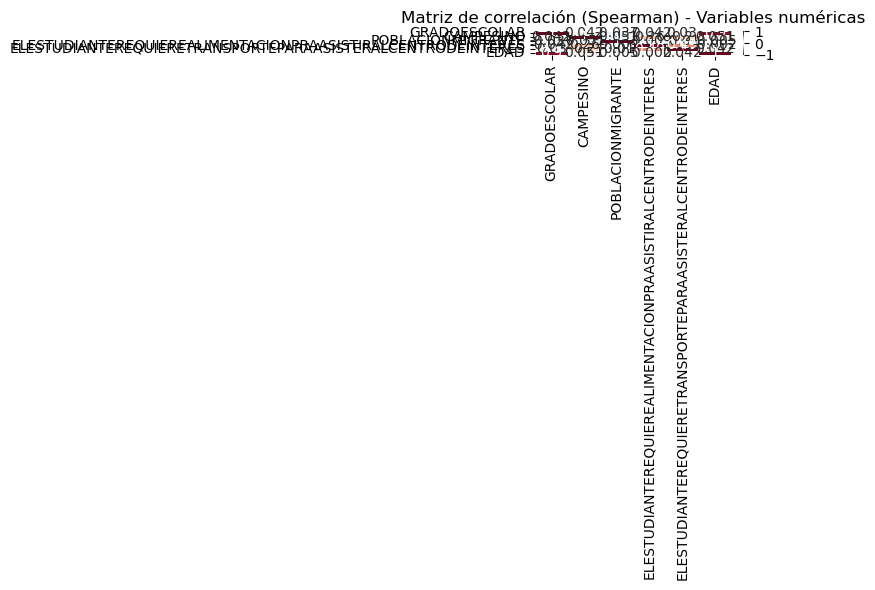

,URBANO_RURAL,SEXO,PERTENENCIAETNICA,FECHAREGISRO
URBANO_RURAL,1.000,0.030,0.183,0.275
SEXO,0.030,1.000,0.031,0.059
PERTENENCIAETNICA,0.183,0.031,1.000,0.382
FECHAREGISRO,0.275,0.059,0.382,1.000


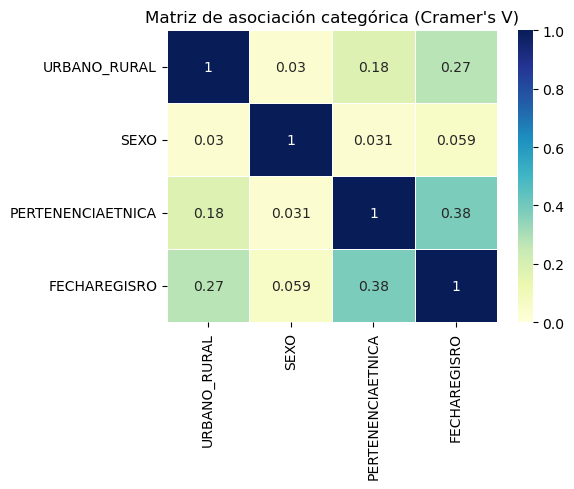

In [3]:
# === 1) Cargar librerías
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# === 2) Leer el CSV (separador ; )
ruta = "ArchivoBeneficiariosInicial.csv"  # cambia si tu archivo tiene otro nombre
df = pd.read_csv(ruta, sep=";", engine="python", dtype=str, encoding="utf-8", quoting=3)


# === 3) Fechas y EDAD
df["FECHANACIMIENTODDMMAAAA"] = df["FECHANACIMIENTODDMMAAAA"].str.replace(" 00:00:00.0000000","", regex=False)
df["FECHAREGISRO"] = df["FECHAREGISRO"].astype(str)

nac = pd.to_datetime(df["FECHANACIMIENTODDMMAAAA"], errors="coerce", format="%Y-%m-%d")
# Si el formato anterior falla masivamente, intenta día/mes/año:
if nac.isna().mean() > 0.95:
    nac = pd.to_datetime(df["FECHANACIMIENTODDMMAAAA"], errors="coerce", dayfirst=True, infer_datetime_format=True)

reg = pd.to_datetime(df["FECHAREGISRO"], errors="coerce", dayfirst=True, infer_datetime_format=True)
hoy = pd.Timestamp("today").normalize()
ref = reg.fillna(hoy)
df["EDAD"] = (ref - nac).dt.days / 365.25

# === 4) Normalización numérica (coma → punto, quitar ruido) y selección de columnas útiles
def a_num(s: pd.Series) -> pd.Series:
    s2 = s.astype(str)
    s2 = s2.str.replace(r"[^0-9,\\.eE\\-\\+]", "", regex=True)  # conservar dígitos, coma/punto, E, signos
    s2 = s2.str.replace(",", ".", regex=False)                  # coma decimal → punto
    s2 = s2.str.replace("++", "+", regex=False)
    s2 = s2.replace({"": np.nan, "+": np.nan, "-": np.nan, ".": np.nan})
    return pd.to_numeric(s2, errors="coerce")

# Variables numéricas/bool de interés (ajusta según tu análisis)
candidatas = [
    "GRADOESCOLAR",
    "ANIO",
    "CAMPESINO",
    "PERSONACONDISCAPACIDAD",
    "POBLACIONMIGRANTE",
    "ELESTUDIANTEREQUIEREALIMENTACIONPRAASISTIRALCENTRODEINTERES",
    "ELESTUDIANTEREQUIERETRANSPORTEPARAASISTERALCENTRODEINTERES"
]
num_df = pd.DataFrame()
for c in candidatas:
    if c in df.columns:
        # Intenta numérico directo
        col = a_num(df[c])
        # Si todo NaN, interpreta SI/NO como 1/0
        if col.isna().all():
            col = df[c].str.upper().str.strip().map({"SI":1, "SÍ":1, "NO":0, "1":1, "0":0})
            col = pd.to_numeric(col, errors="coerce")
        num_df[c] = col

# Añadir EDAD
num_df["EDAD"] = df["EDAD"]

# (Opcional) Excluir identificadores (ID, códigos) para evitar correlación espuria
# num_df = num_df.drop(columns=["ID"], errors="ignore")

# Quitar columnas casi vacías o constantes
mask_dense = num_df.notna().mean() >= 0.6
mask_var = num_df.std(numeric_only=True) > 0
num_df = num_df.loc[:, mask_dense & mask_var]

# === 5) Matriz de correlación (Spearman)
corr_s = num_df.corr(method="spearman").round(3)
display(corr_s)


# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_s, annot=True, cmap="RdBu_r", vmin=-1, vmax=1, linewidths=.5)
plt.title("Matriz de correlación (Spearman) - Variables numéricas", fontsize=12)
plt.tight_layout()
plt.show()

# === 6) Asociación categórica (Cramer's V) para variables de baja cardinalidad
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    if tabla.size == 0 or min(tabla.shape) == 1:
        return np.nan
    chi2, p, dof, expected = chi2_contingency(tabla)
    n = tabla.to_numpy().sum()
    return np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))

# Ejemplo: categorías con <= 30 valores únicos (ajusta la lista según tu interés)
cat_cols = []
for c in ["URBANO_RURAL", "SEXO", "PERTENENCIAETNICA", "FECHAREGISRO"]:
    if c in df.columns:
        u = df[c].nunique(dropna=True)
        if 2 <= u <= 30:
            cat_cols.append(c)

cat_mat = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for i, c1 in enumerate(cat_cols):
    for j, c2 in enumerate(cat_cols[i:], start=i):
        v = cramers_v(df[c1], df[c2])
        cat_mat.loc[c1, c2] = v
        cat_mat.loc[c2, c1] = v

display(cat_mat.round(3))

plt.figure(figsize=(6,5))
sns.heatmap(cat_mat.astype(float), annot=True, cmap="YlGnBu", vmin=0, vmax=1, linewidths=.5)
plt.title("Matriz de asociación categórica (Cramer's V)", fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\Bibiana\AppData\Local\Temp\ipykernel_8876\1161645096.py:35: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  reg = pd.to_datetime(df["FECHAREGISRO"], errors="coerce", dayfirst=True, infer_datetime_format=True)


,GRADO,CAMPESINO,MIGRANTE,REQ_ALIMENTACION,REQ_TRANSPORTE,EDAD
GRADO,1.000,0.045,-0.039,-0.037,0.032,0.907
CAMPESINO,0.045,1.000,-0.051,0.259,0.203,0.051
MIGRANTE,-0.039,-0.051,1.000,-0.009,-0.010,-0.005
REQ_ALIMENTACION,-0.037,0.259,-0.009,1.000,0.492,-0.002
REQ_TRANSPORTE,0.032,0.203,-0.010,0.492,1.000,0.042
EDAD,0.907,0.051,-0.005,-0.002,0.042,1.000


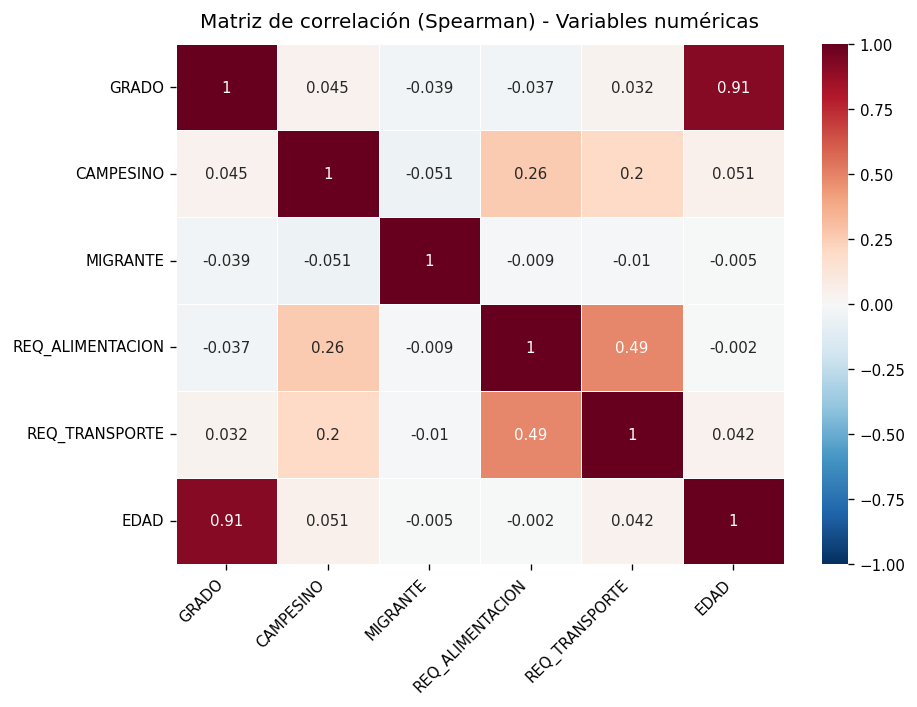

Listo: se generaron matriz_correlacion_spearman.csv y correlacion_spearman.png


In [5]:
# =========================
# 0) Librerías
# =========================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9
})

# =========================
# 1) Cargar el archivo
# =========================
ruta = "ArchivoBeneficiariosInicial.csv"  # cambia si tu archivo tiene otro nombre
df = pd.read_csv(ruta, sep=";", engine="python", dtype=str, encoding="utf-8", quoting=3)

# =========================
# 2) Fechas y EDAD
# =========================
df["FECHANACIMIENTODDMMAAAA"] = df["FECHANACIMIENTODDMMAAAA"].str.replace(" 00:00:00.0000000","", regex=False)
df["FECHAREGISRO"] = df["FECHAREGISRO"].astype(str)

nac = pd.to_datetime(df["FECHANACIMIENTODDMMAAAA"], errors="coerce", format="%Y-%m-%d")
# Si no reconoció casi nada, intenta día/mes/año automáticamente
if nac.isna().mean() > 0.95:
    nac = pd.to_datetime(df["FECHANACIMIENTODDMMAAAA"], errors="coerce", dayfirst=True, infer_datetime_format=True)

reg = pd.to_datetime(df["FECHAREGISRO"], errors="coerce", dayfirst=True, infer_datetime_format=True)
hoy = pd.Timestamp("today").normalize()
ref = reg.fillna(hoy)
df["EDAD"] = (ref - nac).dt.days / 365.25

# =========================
# 3) Normalizador numérico
# =========================
def a_num(s: pd.Series) -> pd.Series:
    s2 = s.astype(str)
    s2 = s2.str.replace(r"[^0-9,\.eE\-\+]", "", regex=True)  # conservar dígitos/coma/punto/E/signos
    s2 = s2.str.replace(",", ".", regex=False)               # coma decimal -> punto
    s2 = s2.str.replace("++", "+", regex=False)
    s2 = s2.replace({"": np.nan, "+": np.nan, "-": np.nan, ".": np.nan})
    return pd.to_numeric(s2, errors="coerce")

# =========================
# 4) Selección de columnas de interés (numéricas/bool)
# =========================
candidatas = [
    "GRADOESCOLAR",
    "ANIO",
    "CAMPESINO",
    "PERSONACONDISCAPACIDAD",
    "POBLACIONMIGRANTE",
    "ELESTUDIANTEREQUIEREALIMENTACIONPRAASISTIRALCENTRODEINTERES",
    "ELESTUDIANTEREQUIERETRANSPORTEPARAASISTERALCENTRODEINTERES"
]

num_df = pd.DataFrame()
for c in candidatas:
    if c in df.columns:
        col = a_num(df[c])
        if col.isna().all():
            # Mapear SI/NO a 1/0 si viniera como texto
            col = df[c].str.upper().str.strip().map({"SI":1, "SÍ":1, "NO":0, "1":1, "0":0})
            col = pd.to_numeric(col, errors="coerce")
        num_df[c] = col

# Añadir EDAD
num_df["EDAD"] = df["EDAD"]

# =========================
# 5) Renombrar a etiquetas cortas
# =========================
renombres = {
    "ELESTUDIANTEREQUIEREALIMENTACIONPRAASISTIRALCENTRODEINTERES": "REQ_ALIMENTACION",
    "ELESTUDIANTEREQUIERETRANSPORTEPARAASISTERALCENTRODEINTERES": "REQ_TRANSPORTE",
    "GRADOESCOLAR": "GRADO",
    "PERSONACONDISCAPACIDAD": "DISCAPACIDAD",
    "POBLACIONMIGRANTE": "MIGRANTE"
}
num_df = num_df.rename(columns=renombres)

# =========================
# 6) Limpieza final: quitar columnas casi vacías o constantes
# =========================
mask_dense = num_df.notna().mean() >= 0.6   # al menos 60% con dato
mask_var = num_df.std(numeric_only=True) > 0 # con variación
num_df = num_df.loc[:, mask_dense & mask_var]

# =========================
# 7) Matriz de correlación (Spearman) + Heatmap
# =========================
corr_s = num_df.corr(method="spearman").round(3)
display(corr_s)

plt.figure(figsize=(8,6))
ax = sns.heatmap(
    corr_s, annot=True, cmap="RdBu_r",
    vmin=-1, vmax=1, linewidths=.5, annot_kws={"fontsize":9}
)
ax.set_title("Matriz de correlación (Spearman) - Variables numéricas", pad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# =========================
# (Opcional) Guardar a archivos
# =========================
corr_s.to_csv("matriz_correlacion_spearman.csv", index=True, encoding="utf-8")
plt.figure(figsize=(8,6))
ax = sns.heatmap(
    corr_s, annot=True, cmap="RdBu_r", vmin=-1, vmax=1, linewidths=.5, annot_kws={"fontsize":9}
)
ax.set_title("Matriz de correlación (Spearman) - Variables numéricas", pad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("correlacion_spearman.png", dpi=160)
plt.close()
print("Listo: se generaron matriz_correlacion_spearman.csv y correlacion_spearman.png")

C:\Users\Bibiana\AppData\Local\Temp\ipykernel_8876\1146569321.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = corr.round(3).astype(str) + pval.applymap(lambda x: "*" if x < 0.05 else "")


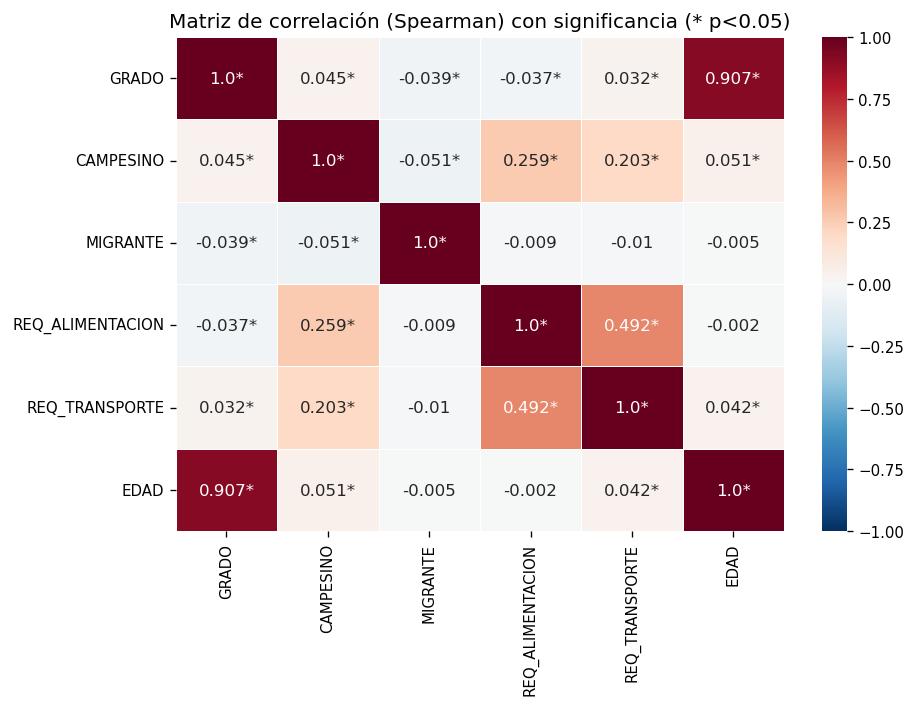

In [6]:
from scipy.stats import spearmanr
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cols = num_df.columns
corr = pd.DataFrame(index=cols, columns=cols, dtype=float)
pval = pd.DataFrame(index=cols, columns=cols, dtype=float)

for i, c1 in enumerate(cols):
    for j, c2 in enumerate(cols):
        r, p = spearmanr(num_df[c1], num_df[c2], nan_policy='omit')
        corr.loc[c1, c2] = r
        pval.loc[c1, c2] = p

# Anotaciones con asterisco si p<0.05
annot = corr.round(3).astype(str) + pval.applymap(lambda x: "*" if x < 0.05 else "")
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=annot, fmt="", cmap="RdBu_r", vmin=-1, vmax=1, linewidths=.5)
plt.title("Matriz de correlación (Spearman) con significancia (* p<0.05)")
plt.tight_layout()
plt.show()
